## 1. Get Dataset

In [1]:
import os
import sys
from pathlib import Path
import scanpy as sc

project_root = Path().absolute().parent
# Append the root of the Git repository to the path.
git_root = os.popen(cmd="git rev-parse --show-toplevel").read().strip()
sys.path.append(git_root)

import pertdata as pt  # noqa: E402

# Use the existing norman dataset location
norman = pt.PertDataset(name="norman", cache_dir_path="../data", silent=False)

print(norman)

Dataset already cached: d:\IML\Genomic-Data-Science\data\norman
Loading: d:\IML\Genomic-Data-Science\data\norman\norman\perturb_processed.h5ad
PertDataset object
    name: norman
    cache_dir_path: d:\IML\Genomic-Data-Science\data
    path: d:\IML\Genomic-Data-Science\data\norman
    adata: AnnData object with n_obs ✕ n_vars = 91205 ✕ 5045


## 2. Load the data


In [2]:
adata = sc.read_h5ad('../data/norman/norman/perturb_processed.h5ad')
print(f"Dataset loaded: {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Available metadata: {list(adata.obs.columns)}")

Dataset loaded: 91205 cells × 5045 genes
Available metadata: ['condition', 'cell_type', 'dose_val', 'control', 'condition_name']


## 3. Prepare Data

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
import numpy as np

# Keep data SPARSE - do not convert to dense
X = adata.X  # Keep as sparse matrix
print(f"Gene expression matrix: {X.shape} (sparse: {type(X).__name__})")

y_labels = adata.obs['condition'].values
print(f"Labels shape: {y_labels.shape}")
print(f"Unique perturbations: {len(set(y_labels))}")
print(f"Sample labels: {y_labels[:5]}")



# Encode string labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)
print(f"\nEncoded labels range: {y.min()} to {y.max()}")

# Split into train/test (80/20) - NO SUBSAMPLING /  Undersqampling, using full dataset
print("\n" + "="*50)
print("Using FULL dataset (sparse format)")
print("="*50)
random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)

print(f"\nTraining data: X_train.shape={X_train.shape}")
print(f"Test data: X_test.shape={X_test.shape}")
print(f"Memory usage: ~{X_train.data.nbytes / 1e6:.1f} MB (sparse)")


Gene expression matrix: (91205, 5045) (sparse: csr_matrix)
Labels shape: (91205,)
Unique perturbations: 284
Sample labels: ['TSC22D1+ctrl', 'KLF1+MAP2K6', 'ctrl', 'CEBPE+RUNX1T1', 'MAML2+ctrl']
Categories (284, object): ['AHR+FEV', 'AHR+KLF1', 'AHR+ctrl', 'ARID1A+ctrl', ..., 'ZC3HAV1+HOXC13', 'ZC3HAV1+ctrl', 'ZNF318+FOXL2', 'ZNF318+ctrl']

Encoded labels range: 0 to 283

Using FULL dataset (sparse format)

Training data: X_train.shape=(72964, 5045)
Test data: X_test.shape=(18241, 5045)
Memory usage: ~119.4 MB (sparse)


## 4. Classification

In [9]:
from src.models.svm_model import LinearSVMClassifier
import time
''' C: 0.008416315395715555
  loss: squared_hinge
  max_iter: 909
  tol: 0.0007056401403169878'''
model = LinearSVMClassifier(
    C = 0.008416315395715555,
    max_iter = 2000,
    tol = 0.0007056401403169878,
    class_weight="balanced",
    n_components=200,
    random_state = 42,
    verbose = 1,                   
)
print("\n" + "H" * 50)
print("TRAINING SVM")
print("="*50)
start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time
results = model.evaluate(X_test, y_test)
print("\n" + "H" * 50)
print("R E S U L T")
print("="*50)
for metric, value in results.items():
    print(f"  {metric}: {value:.4f}")



HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
TRAINING SVM
TruncatedSVD: 5045 → 200 features
Explained variance: 12.63%
[LibLinear]
HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH
R E S U L T
  accuracy: 0.2315
  precision: 0.2124
  recall: 0.2315
  f1_score: 0.1975


## 5. Results


ROC CURVE ANALYSIS (Multi-class)

Number of classes: 284
Test samples: 18241

ROC AUC Scores:
  Micro-average: 0.8964
  Macro-average: 0.8718

 ROC curves saved to ../docs/roc_curve_multiclass.png


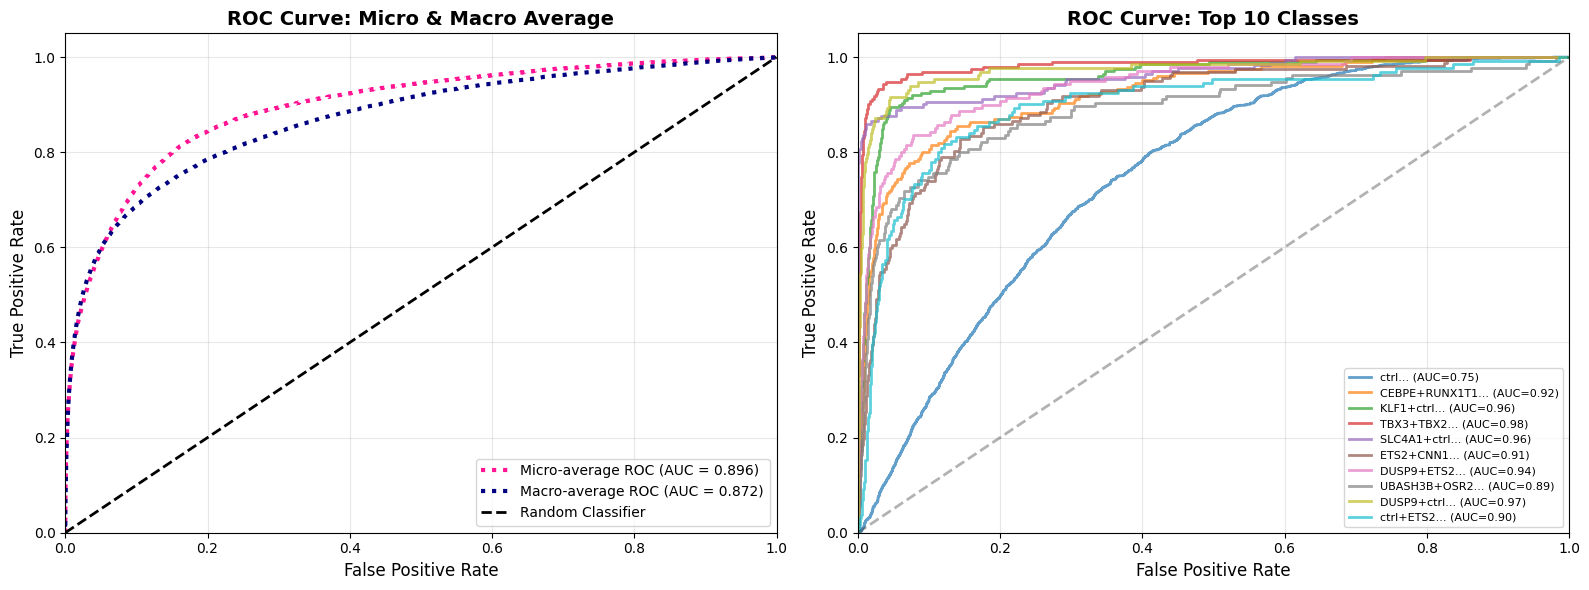


Per-Class ROC AUC Scores (Top 20):
   1. MAPK1+PRTG                    : AUC=0.9915 ( 76 test samples)
   2. IRF1+SET                      : AUC=0.9885 ( 73 test samples)
   3. FEV+CBFA2T3                   : AUC=0.9883 ( 31 test samples)
   4. DUSP9+KLF1                    : AUC=0.9874 ( 64 test samples)
   5. ctrl+COL2A1                   : AUC=0.9858 ( 45 test samples)
   6. CEBPE+SPI1                    : AUC=0.9856 ( 35 test samples)
   7. TBX3+TBX2                     : AUC=0.9835 (194 test samples)
   8. SET+KLF1                      : AUC=0.9833 (108 test samples)
   9. DUSP9+PRTG                    : AUC=0.9815 ( 48 test samples)
  10. IRF1+ctrl                     : AUC=0.9809 ( 66 test samples)
  11. DUSP9+IGDCC3                  : AUC=0.9764 ( 65 test samples)
  12. KLF1+FOXA1                    : AUC=0.9753 ( 65 test samples)
  13. AHR+FEV                       : AUC=0.9752 ( 53 test samples)
  14. ETS2+IKZF3                    : AUC=0.9745 ( 78 test samples)
  15. COL2A1

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("\n" + "="*70)
print("ROC CURVE ANALYSIS (Multi-class)")
print("="*70)

# Get decision function scores for all classes
y_scores = model.predict_decision_function(X_test)

# Binarize the labels (one-vs-rest)
n_classes = len(np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

print(f"\nNumber of classes: {n_classes}")
print(f"Test samples: {len(y_test)}")

# Compute ROC curve and ROC area for each class
fpr = dict() # false positive rate
tpr = dict() # true positive rate
roc_auc = dict() # area under the curve

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_scores.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print(f"\nROC AUC Scores:")
print(f"  Micro-average: {roc_auc['micro']:.4f}")
print(f"  Macro-average: {roc_auc['macro']:.4f}")

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Micro and Macro average
ax1 = axes[0]
ax1.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=3)
ax1.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=3)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve: Micro & Macro Average', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(alpha=0.3)

# Right plot: Per-class ROC curves (top 10 most frequent classes)
ax2 = axes[1]

# Get top 10 most frequent classes
class_counts = np.bincount(y_train)
top_classes = np.argsort(class_counts)[-10:][::-1]

# Use a colormap for different classes
colors = plt.cm.tab10(np.linspace(0, 1, len(top_classes)))

for idx, class_id in enumerate(top_classes):
    class_label = label_encoder.inverse_transform([class_id])[0]
    ax2.plot(fpr[class_id], tpr[class_id], color=colors[idx],
            linewidth=2, alpha=0.7,
            label=f'{class_label[:20]}... (AUC={roc_auc[class_id]:.2f})')

ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.3)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title(f'ROC Curve: Top 10 Classes', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/roc_curve_multiclass.png', dpi=150, bbox_inches='tight')
print(f"\n ROC curves saved to ../docs/roc_curve_multiclass.png")
plt.show()

# Show per-class AUC for all classes
print(f"\n" + "="*70)
print(f"Per-Class ROC AUC Scores (Top 20):")
print("="*70)
class_auc_sorted = sorted([(i, roc_auc[i]) for i in range(n_classes)], 
                           key=lambda x: x[1], reverse=True)
for rank, (class_id, auc_score) in enumerate(class_auc_sorted[:20], 1):
    class_label = label_encoder.inverse_transform([class_id])[0]
    samples = (y_test == class_id).sum()
    print(f"  {rank:2d}. {class_label:30s}: AUC={auc_score:.4f} ({samples:3d} test samples)")

In [ ]:
model.save('../models/linear_svm_model.pkl')

Model saved to ../models/linear_svm_model.pkl


## Optional: Hyperparameter Search (We used beyes)

In [ ]:
from skopt import BayesSearchCV
from src.models.svm_model import LinearSVMClassifier
from skopt.space import Real, Integer, Categorical
from sklearn.decomposition import TruncatedSVD
# Create the custom classifier
base_model = LinearSVMClassifier(random_state=42)

# Search space now includes min_samples!
search_spaces = {
    'C': Real(1e-3, 1e2, prior='log-uniform'),
    'max_iter': Integer(300, 2000),
    'tol': Real(1e-5, 1e-2, prior='log-uniform'),
    'class_weight': Categorical([None, 'balanced']),
    'n_components': Integer(50, 300),
}


model_name = "linear_svm_model_bayes_opt"



X_train_bayes, X_test_bayes, y_train_bayes, y_test_bayes = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

bayes_search = BayesSearchCV(
    estimator=base_model,
    search_spaces=search_spaces,
    n_iter=16,  # Number of parameter settings that are sampled
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# Train Bayesian optimization
print("\n" + "="*50)
print(f"Starting Bayesian Optimization for {model_name}...")
print("="*50)

start_time = time.time()
bayes_search.fit(X_train_bayes, y_train_bayes)
end_time = time.time()
print(f"Bayesian optimization took {end_time - start_time:.2f} seconds")

# Results
print("\n" + "="*50)
print(f"BEST HYPERPARAMETERS FOUND ({model_name}):")
print("="*50)
for param, value in bayes_search.best_params_.items():
    print(f"  {param}: {value}")

# Test set evaluation
y_pred_bayes = bayes_search.best_estimator_.predict(X_test_bayes)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc_bayes = accuracy_score(y_test_bayes, y_pred_bayes)
prec_bayes, rec_bayes, f1_bayes, _ = precision_recall_fscore_support(
    y_test_bayes, y_pred_bayes, average='weighted', zero_division=0
)

print("\n" + "="*50)
print(f"TEST SET PERFORMANCE (Bayesian {model_name}):")
print("="*50)
print(f"  accuracy:  {acc_bayes:.4f}")
print(f"  precision: {prec_bayes:.4f}")
print(f"  recall:    {rec_bayes:.4f}")
print(f"  f1_score:  {f1_bayes:.4f}")

ModuleNotFoundError: No module named 'src.models.base_model'